# Projeto AWS: O Peso das Palavras
---

## Problema de Negócio
Em marketplaces digitais, nem sempre os clientes atribuem notas coerentes com seus comentários, ou até mesmo deixam de avaliar numericamente um produto. Dessa forma, surge a necessidade de desenvolver modelos que consigam interpretar automaticamente o sentimento do texto e convertê-lo em uma nota de satisfação.

## Objetivo
Construir um modelo preditivo capaz de estimar a nota de um produto (de 1 a 5) com base no conteúdo textual dos comentários.
O Desafio Técnico: utilizar um modelo de Regressão Linear para encontrar a relação entre o "tom" do texto e a "nota" atribuída.

In [ ]:
# !pip install pandas tqdm matplotlib seaborn nltk leia-br transformers torch pysentimiento

In [2]:
# Gerais
import re
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import warnings
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import confusion_matrix
tqdm.pandas()
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Análise de Sentimento
import nltk
from nltk.corpus import stopwords
from LeIA import SentimentIntensityAnalyzer as LEIAAnalyzer
from nltk.sentiment import SentimentIntensityAnalyzer as VaderAnalyzer
from transformers import pipeline
from pysentimiento import create_analyzer
from tqdm import tqdm
import torch

In [5]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

## 1. Leitura das tabelas

Nesta etapa carregamos a tabela do dataset que será utilizada no projeto.
O foco principal da análise está na tabela de **avaliações**, que contém informações textuais escritas pelos consumidores, além das notas atribuídas aos produtos.

A leitura inicial dos dados permite compreender:

- estrutura das tabelas
- quantidade de registros
- variáveis disponíveis
- valores nulos e duplicatas

In [ ]:
import pandas as pd
import os

path = './bronze'

dfs = {}

for file in os.listdir(path):
  if file.endswith('.csv'):
    df_name = "df_" + file.replace(".csv", "")
    full_path = os.path.join(path, file)

    dfs[df_name] = pd.read_csv(full_path)

In [ ]:
resultado = []

for nome, df in dfs.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    duplicatas = df.duplicated().sum()

    # Caso não tenha nulos
    if nulos.empty:
        resultado.append({
            "dataset": nome,
            "shape": df.shape,
            "coluna": None,
            "nulos": 0,
            "pct_nulos": 0.0,
            "duplicatas": duplicatas
        })
    else:
        for col, qtd in nulos.items():
            resultado.append({
                "dataset": nome,
                "shape": df.shape,
                "coluna": col,
                "nulos": qtd,
                "pct_nulos": round((qtd / len(df)) * 100, 1),
                "duplicatas": duplicatas
            })

df_resumo = pd.DataFrame(resultado)
display(df_resumo)

,dataset,shape,coluna,nulos,pct_nulos,duplicatas
0,df_avaliacoes,"(99224, 7)",review_comment_title,87656,88.3,0
1,df_avaliacoes,"(99224, 7)",review_comment_message,58247,58.7,0
2,df_clientes,"(99441, 5)",None,0,0.0,0
3,df_geolocalizacao,"(1000163, 5)",None,0,0.0,261831
4,df_itens_pedidos,"(112650, 7)",None,0,0.0,0
5,df_pagamentos,"(103886, 5)",None,0,0.0,0
6,df_pedidos,"(99441, 8)",order_approved_at,160,0.2,0
7,df_pedidos,"(99441, 8)",order_delivered_carrier_date,1783,1.8,0
8,df_pedidos,"(99441, 8)",order_delivered_customer_date,2965,3.0,0
9,df_produtos,"(32951, 9)",product_category_name,610,1.9,0


## 2. Transformação e Limpeza

### Tabela de Avaliações

Antes da aplicação dos modelos de análise de sentimento, os dados textuais passam por um processo de transformação e limpeza com o objetivo de comparar a qualidade das análises realizadas.

Nesta etapa serão realizadas:

- Validação dos tipos de dados
- Unificação dos campos textuais
- Tratamento de valores nulos
- Padronização da escrita
- Remoção de caracteres desnecessários
- Remoção de stopwords

### 2.1 Tipificação dos dados

In [ ]:
# STRINGS
dfs['df_avaliacoes']['review_id'] = dfs['df_avaliacoes']['review_id'].astype('string')
dfs['df_avaliacoes']['order_id'] = dfs['df_avaliacoes']['order_id'].astype('string')
dfs['df_avaliacoes']['review_comment_message'] = dfs['df_avaliacoes']['review_comment_message'].astype('string')
dfs['df_avaliacoes']['review_comment_title'] = dfs['df_avaliacoes']['review_comment_title'].astype('string')

# INT
dfs['df_avaliacoes']['review_score'] = dfs['df_avaliacoes']['review_score'].astype('int8') # int8 = economia de memória

# DATA
dfs['df_avaliacoes']['review_creation_date'] = pd.to_datetime(dfs['df_avaliacoes']['review_creation_date'], errors='coerce')
dfs['df_avaliacoes']['review_answer_timestamp'] = pd.to_datetime(dfs['df_avaliacoes']['review_answer_timestamp'], errors='coerce')

dfs['df_avaliacoes'].dtypes

review_id                  string[python]
order_id                   string[python]
review_score                         int8
review_comment_title       string[python]
review_comment_message     string[python]
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

### 2.2 Coluna de texto unificada e dados nulos

**2.2.1 Validando casos onde existe título e não existe comentário**

In [ ]:
total = len(dfs['df_avaliacoes'])
count = dfs['df_avaliacoes'][
    dfs['df_avaliacoes']["review_comment_title"].notna() & dfs['df_avaliacoes']["review_comment_message"].isna()
].shape[0]

percent = (count / total) * 100
print(f"{count} linhas ({percent:.2f}%)")

1729 linhas (1.74%)


**2.2.2 Criando coluna unificada com título e comentário**

In [ ]:
df_avaliacao = dfs['df_avaliacoes'].copy()

# substitui nulos por string vazia para concatenação
df_avaliacao['review_comment_message'] = df_avaliacao['review_comment_message'].fillna('')
df_avaliacao['review_comment_title'] = df_avaliacao['review_comment_title'].fillna('')

df_avaliacao['review_text'] = (
    df_avaliacao['review_comment_title'] + ' ' + df_avaliacao['review_comment_message']
).str.strip()

# definindo valores vazios para "sem comentários"
df_avaliacao['review_text'] = df_avaliacao['review_text'].replace('', 'sem comentários')

percentual = round((df_avaliacao['review_text'] == 'sem comentários').mean() * 100,2)
print(f"Percentual de valores 'sem comentários' em 'review_text': {percentual}")
df_avaliacao[['review_comment_title', 'review_comment_message', 'review_text']].head(10)

Percentual de valores 'sem comentários' em 'review_text': 56.98


,review_comment_title,review_comment_message,review_text
0,,,sem comentários
1,,,sem comentários
2,,,sem comentários
3,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.
4,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela I...
5,,,sem comentários
6,,,sem comentários
7,,,sem comentários
8,,,sem comentários
9,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente. no site a marca ...


**2.2.3 Removendo linhas sem comentários**

In [ ]:
df_avaliacao = df_avaliacao[
    df_avaliacao['review_text'] != 'sem comentários'
].copy()

print(f"Quantidade de linhas atuais: {df_avaliacao.shape[0]}")

Quantidade de linhas atuais: 42686


### 2.3 Padronizando textos da coluna unificada "review_text"

**2.3.1 Padronização:**
- Tudo minúsculo
- Remoção de acentos e pontuações
- Remoção de espaços extras

In [ ]:
import unicodedata
import re

def standardize(text):
  if pd.isnull(text):
    return text

  # minúsculo
  text = text.lower()

  # remove acentos
  text = ''.join(
      c for c in unicodedata.normalize('NFD', text) # NFD: quebra caracteres acentuados em partes separadas (á -> "a" + "´")
      if unicodedata.category(c) != 'Mn' # valida o tipo do caractere (Mn: acentos e diacríticos)
  )

  # remover pontuações
  text = re.sub(r'[^\w\s]', '', text) # substitui tudo que não é letra\número\espaço por ""

  # remover múltiplos espaços
  text = re.sub(r'\s+', ' ', text).strip()

  # garante separação correta de palavras
  palavras = re.findall(r'\b\w+\b', text)
  text = ' '.join(palavras)

  return text

df_avaliacao['review_text_modificado'] = df_avaliacao['review_text'].apply(standardize)

**2.3.2 Removendo stopwords**

_Stopwords_ são palavras comuns que geralmente não carregam muito significado relevante para a análise, como: "o", "a", "de", "da", "para", "com"...

In [ ]:
stop_words = set(stopwords.words('portuguese'))

def remover_stopwords(texto):
    if pd.isna(texto):
        return None, []
    tokens = texto.split()
    removidas = [t for t in tokens if t in stop_words]
    tokens = [t for t in tokens if t not in stop_words]
    return (' '.join(tokens) if tokens else None), removidas

resultados = df_avaliacao['review_text_modificado'].apply(remover_stopwords)
df_avaliacao['review_text_modificado'] = resultados.apply(lambda x: x[0])
df_avaliacao['stopwords_removidas'] = resultados.apply(lambda x: x[1])

df_avaliacao = df_avaliacao[df_avaliacao['review_text_modificado'].notna()]

# Verificar exemplo
exemplo = df_avaliacao[df_avaliacao['review_text_modificado'].notna()].iloc[0]
removidas = exemplo['stopwords_removidas']

print(f"Nota: {exemplo['review_score']}")
print(f"Original:  {exemplo['review_text']}")
print(f"Modificado:     {exemplo['review_text_modificado']}")
print(f"\nQuantidade de stopwords removidas: {len(removidas)}")
print(f"Stopwords: {removidas}")

Nota: 5
Original:  Recebi bem antes do prazo estipulado.
Modificado:     recebi bem antes prazo estipulado

Quantidade de stopwords removidas: 1
Stopwords: ['do']


**2.3.3 Removendo colunas que não serão utilizadas**

In [ ]:
df_avaliacao = df_avaliacao.drop(columns=['order_id', 'review_creation_date','review_answer_timestamp','review_comment_title', 'review_comment_message', 'review_id'])

**2.3.4 Salvando base final**

In [ ]:
df_avaliacao.sample(5, random_state=32)

,review_score,review_text,review_text_modificado,stopwords_removidas
59551,1,Esperava um produto original e veio uma réplic...,esperava produto original veio replica segunda...,"[um, e, uma, de]"
3259,5,"Muito bonito A Luminária é muito bonita, atend...",bonito luminaria bonita atendeu expectativa ch...,"[muito, a, e, muito, minha]"
33804,2,"Eu achei a entrega um pouco demorada,e as espe...",achei entrega pouco demoradae especificacoes e...,"[eu, a, um, as, que, estava, no, a, do]"
60651,5,Bom produto,bom produto,[]
47646,1,O jogo de bolas de bilhar que comprei é totalm...,jogo bolas bilhar comprei totalmente diferente...,"[o, de, de, que, e, do, que, foi, a, e, da, ao..."


In [ ]:
df_avaliacao.to_parquet("./silver/df_avaliacao.parquet", index=False)

## 3. Análise de Sentimento

A análise de sentimento é uma técnica de Processamento de Linguagem Natural (NLP) utilizada para **identificar opiniões, emoções e polaridade presentes em textos**.

Neste projeto, o objetivo é verificar o quanto diferentes modelos conseguem representar corretamente a percepção do consumidor a partir dos comentários realizados nas avaliações.


In [4]:
PARQUET_PATH = "./silver/df_avaliacao.parquet"
df_avaliacao = pd.read_parquet(PARQUET_PATH)

df_avaliacao.head(5)

,review_score,review_text,review_text_modificado,stopwords_removidas
0,5,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado,[do]
1,5,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar intern...,"[pela, e, a]"
2,4,recomendo aparelho eficiente. no site a marca ...,recomendo aparelho eficiente site marca aparel...,"[no, a, do, esta, como, e, ao, esta, com, com,..."
3,4,"Mas um pouco ,travando...pelo valor ta Boa.",pouco travandopelo valor ta boa,"[mas, um]"
4,5,"Super recomendo Vendedor confiável, produto ok...",super recomendo vendedor confiavel produto ok ...,"[e, do]"


**Função padrão que aplica o modelo de sentimento e retorna um DF padronizado**

In [36]:
def aplicar_modelo_sentimento(df, nome_modelo, func_score, coluna_texto):
    """
    Parâmetros:
    - df: DataFrame original
    - nome_modelo: string com nome do modelo (ex: 'leia')
    - func_score: função que recebe texto e retorna score [-1, 1]
    - coluna_texto: coluna com o texto
    """

    df_result = df.copy()

    # Score
    df_result[f'{nome_modelo}_score'] = df_result[coluna_texto].progress_apply(func_score)

    # Retorno padronizado
    return df_result[[coluna_texto, 'review_score',
                      f'{nome_modelo}_score']]

**Classificação usada para modelos contínuos**

In [37]:
def score_para_estrelas(score):

    if score <= -0.6:
        return 1

    elif -0.6 < score <= -0.2:
        return 2

    elif -0.2 < score <= 0.2:
        return 3

    elif 0.2 < score <= 0.6:
        return 4

    else:
        return 5

### 3.1 Vader

O **VADER (Valence Aware Dictionary and sEntiment Reasoner)** é um modelo de análise de sentimento baseado em:

- léxico de palavras
- regras linguísticas
- intensificadores e negações

Originalmente desenvolvido para textos em inglês, o VADER é amplamente utilizado por sua simplicidade e velocidade.

In [ ]:
vader = VaderAnalyzer()

def score_vader(text):
  return vader.polarity_scores(text)['compound']

df_vader = aplicar_modelo_sentimento(df_avaliacao, 'vader', score_vader, 'review_text')
df_vader_modificado = aplicar_modelo_sentimento(df_avaliacao, 'vader', score_vader, 'review_text_modificado')

comparacao_vader = pd.DataFrame({
    'comentario': df_avaliacao['review_text'],
    'nota_real': df_avaliacao['review_score'],

    'vader_score_original': df_vader['vader_score'],
    'vader_score_modificado': df_vader_modificado['vader_score']
})

comparacao_vader.sample(10, random_state=32)

100%|██████████| 42558/42558 [00:11<00:00, 3547.40it/s]


,comentario,nota_real,vader_score_original,vader_score_modificado
59551,Esperava um produto original e veio uma réplic...,1,0.3802,0.3182
3259,"Muito bonito A Luminária é muito bonita, atend...",5,0.0000,0.0000
33804,"Eu achei a entrega um pouco demorada,e as espe...",2,-0.2960,0.0000
60651,Bom produto,5,0.0000,0.0000
47646,O jogo de bolas de bilhar que comprei é totalm...,1,0.0000,0.0000
28157,Perfeito tudo de bom Chegou bem antes da data...,4,0.0000,0.0000
65398,Chegou antes do prazo. Tudo OK.,5,0.4466,0.2960
79124,"Produto entregue antes do prazo, muito bem emb...",5,0.0000,0.0000
52014,O material parece de camelo pelo preço não vale,3,0.0000,0.0000
74668,Bom. Faltou a nota fiscal que não chegou com o...,4,-0.5267,0.0000


In [ ]:
comparacao_vader.to_parquet("./silver/df_vader.parquet")

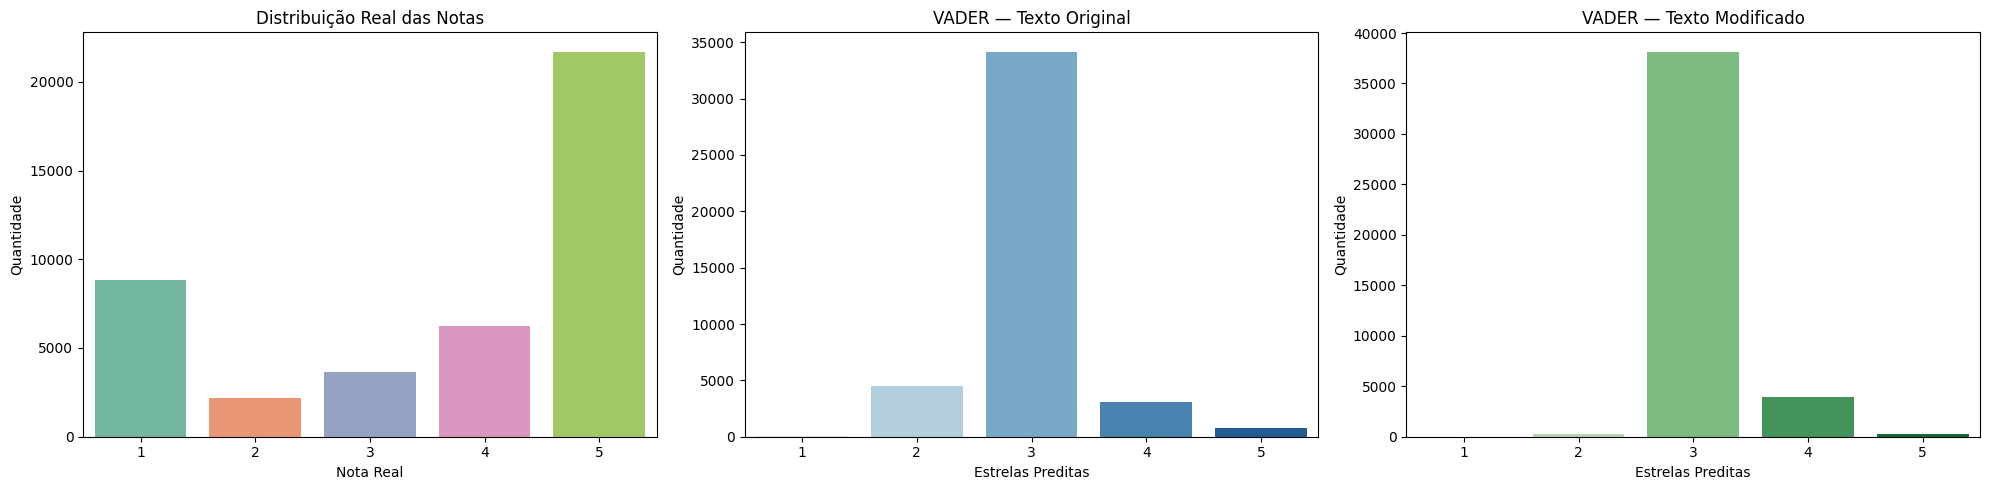

In [31]:
PATH = "./silver/df_vader.parquet"
vader = pd.read_parquet(PATH)

# Transformando score em estrelas
vader['vader_estrelas_original'] = (vader['vader_score_original'].apply(score_para_estrelas))
vader['vader_estrelas_modificado'] = (vader['vader_score_modificado'].apply(score_para_estrelas))

fig, axes = plt.subplots(1, 3, figsize=(20,5))

# GRÁFICO 1 - DISTRIBUIÇÃO REAL DAS NOTAS
sns.countplot(
    data=vader,
    x='nota_real',
    order=[1,2,3,4,5],
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Distribuição Real das Notas')
axes[0].set_xlabel('Nota Real')
axes[0].set_ylabel('Quantidade')

# GRÁFICO 2 - VADER TEXTO ORIGINAL
sns.countplot(
    data=vader,
    x='vader_estrelas_original',
    order=[1,2,3,4,5],
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('VADER — Texto Original')
axes[1].set_xlabel('Estrelas Preditas')
axes[1].set_ylabel('Quantidade')

# GRÁFICO 3 - VADER TEXTO MODIFICADO
sns.countplot(
    data=vader,
    x='vader_estrelas_modificado',
    order=[1,2,3,4,5],
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title('VADER — Texto Modificado')
axes[2].set_xlabel('Estrelas Preditas')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

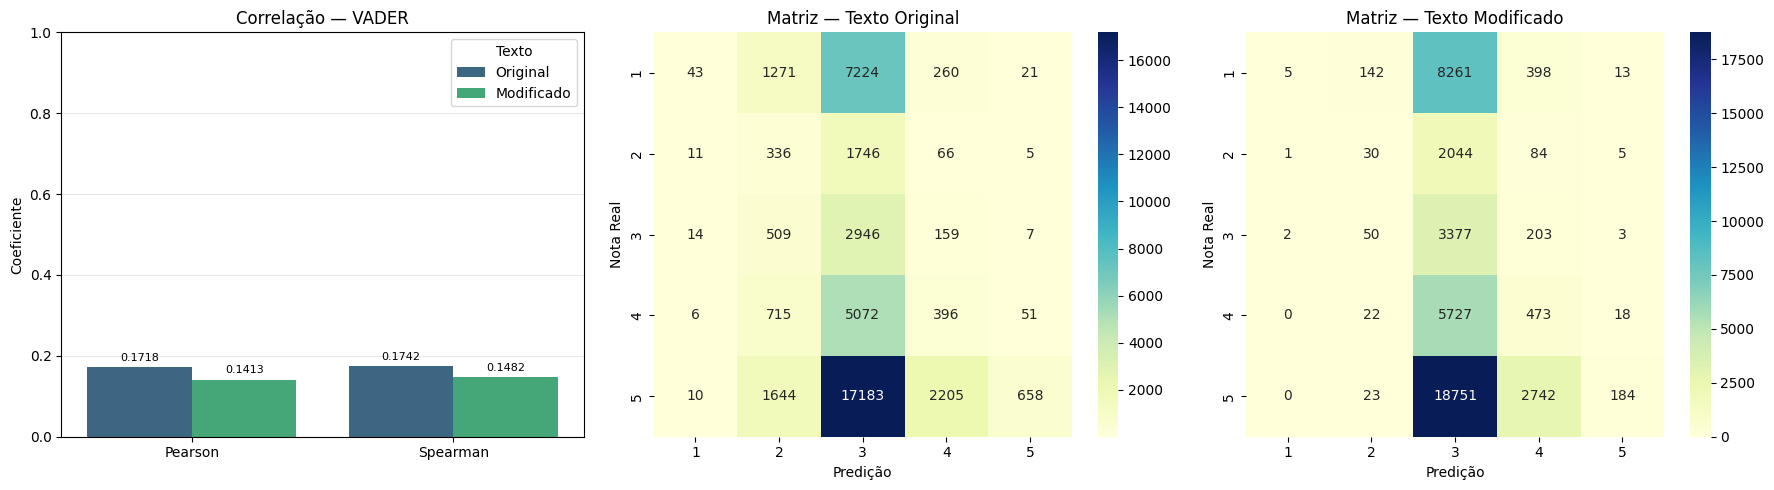

In [45]:
# CORRELAÇÕES
corr = pd.DataFrame({
    'Métrica': ['Pearson', 'Pearson', 'Spearman', 'Spearman'],
    'Texto': ['Original', 'Modificado', 'Original', 'Modificado'],
    'Correlação': [
        pearsonr(vader['nota_real'],vader['vader_estrelas_original'])[0],
        pearsonr(vader['nota_real'],vader['vader_estrelas_modificado'])[0],
        spearmanr(vader['nota_real'],vader['vader_estrelas_original'])[0],
        spearmanr(vader['nota_real'],vader['vader_estrelas_modificado'])[0]
    ]
})

# MATRIZ DE CONFUSÃO
cm_original = confusion_matrix(
    vader['nota_real'],
    vader['vader_estrelas_original'],
    labels=[1,2,3,4,5]
)

cm_modificado = confusion_matrix(
    vader['nota_real'],
    vader['vader_estrelas_modificado'],
    labels=[1,2,3,4,5]
)

# GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ax = sns.barplot(
    data=corr,
    x='Métrica',
    y='Correlação',
    hue='Texto',
    palette='viridis',
    ax=axes[0]
)

for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )

axes[0].set_title('Correlação — VADER')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xlabel('')
axes[0].set_ylim(0,1)

axes[0].grid(axis='y', alpha=0.3)

# MATRIZES
sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[1]
)

axes[1].set_title('Matriz — Texto Original')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Nota Real')

sns.heatmap(
    cm_modificado,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[2]
)

axes[2].set_title('Matriz — Texto Modificado')
axes[2].set_xlabel('Predição')
axes[2].set_ylabel('Nota Real')

plt.tight_layout()
plt.show()

### 3.2 LeIA

O **LeIA** é uma adaptação do VADER para língua portuguesa.

Seu funcionamento é semelhante ao VADER, porém utilizando um léxico adaptado para português brasileiro, tornando-o mais adequado para comentários escritos por consumidores brasileiros.

In [38]:
leia = LEIAAnalyzer()

def score_leia(text):
  return leia.polarity_scores(text)['compound']

df_leia = aplicar_modelo_sentimento(df_avaliacao, 'leia', score_leia, 'review_text')
df_leia_modificado = aplicar_modelo_sentimento(df_avaliacao, 'leia', score_leia, 'review_text_modificado')

comparacao_leia = pd.DataFrame({
    'comentario': df_avaliacao['review_text'],
    'nota_real': df_avaliacao['review_score'],

    'leia_score_original': df_leia['leia_score'],
    'leia_score_modificado': df_leia_modificado['leia_score'],
})

comparacao_leia.sample(20, random_state=32)

100%|██████████| 42558/42558 [00:17<00:00, 2384.52it/s]


,comentario,nota_real,leia_score_original,leia_score_modificado
25605,Esperava um produto original e veio uma réplic...,1,0.6360,0.5994
1434,"Muito bonito A Luminária é muito bonita, atend...",5,0.7506,0.7506
14610,"Eu achei a entrega um pouco demorada,e as espe...",2,-0.2960,-0.2960
26086,Bom produto,5,0.4215,0.4215
20456,O jogo de bolas de bilhar que comprei é totalm...,1,0.0000,0.0000
12203,Perfeito tudo de bom Chegou bem antes da data...,4,0.9100,0.9100
28058,Chegou antes do prazo. Tudo OK.,5,0.3885,0.2263
34030,"Produto entregue antes do prazo, muito bem emb...",5,0.5983,0.5574
22372,O material parece de camelo pelo preço não vale,3,-0.2960,-0.2960
32089,Bom. Faltou a nota fiscal que não chegou com o...,4,-0.4215,-0.4215


In [39]:
comparacao_leia.to_parquet("./silver/df_leia.parquet")

In [40]:
PATH = "./silver/df_leia.parquet"
leia = pd.read_parquet(PATH)
leia.head(5)

,comentario,nota_real,leia_score_original,leia_score_modificado
0,Recebi bem antes do prazo estipulado.,5,0.2732,0.2732
1,Parabéns lojas lannister adorei comprar pela I...,5,0.9413,0.9413
2,recomendo aparelho eficiente. no site a marca ...,4,0.6486,0.6486
3,"Mas um pouco ,travando...pelo valor ta Boa.",4,0.7264,0.6151
4,"Super recomendo Vendedor confiável, produto ok...",5,0.8979,0.8979


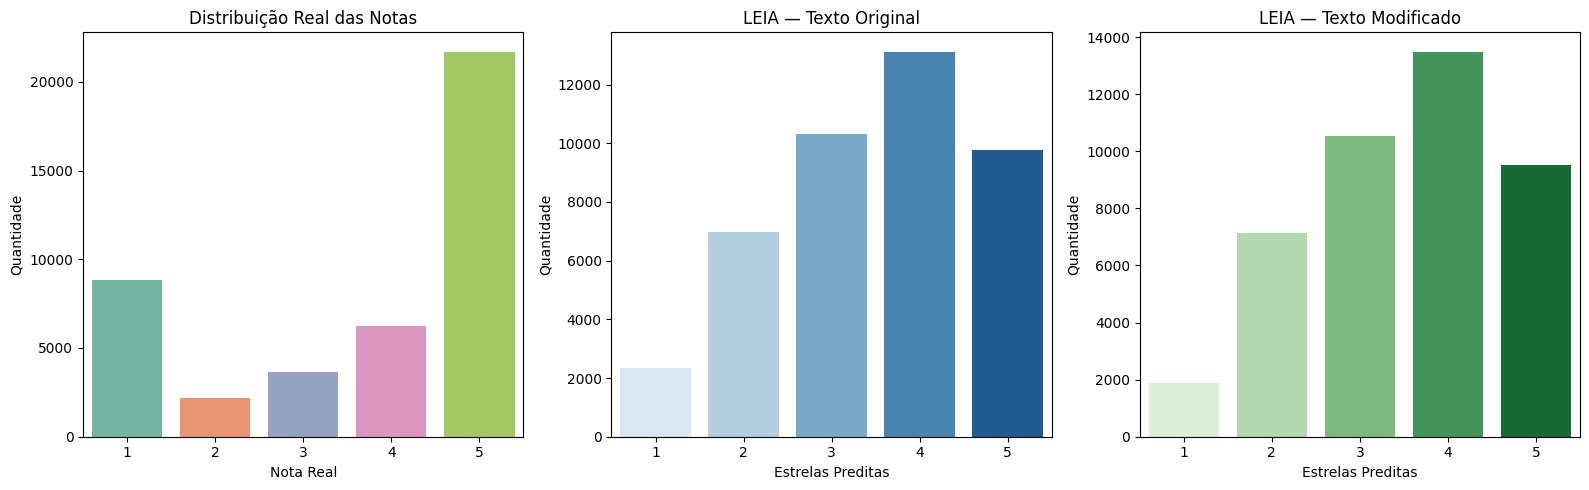

In [42]:
PATH = "./silver/df_leia.parquet"
leia = pd.read_parquet(PATH)

# Transformando score em estrelas
leia['leia_estrelas_original'] = (leia['leia_score_original'].apply(score_para_estrelas))
leia['leia_estrelas_modificado'] = (leia['leia_score_modificado'].apply(score_para_estrelas))

fig, axes = plt.subplots(1, 3, figsize=(16,5))

# GRÁFICO 1 - DISTRIBUIÇÃO REAL DAS NOTAS
sns.countplot(
    data=leia,
    x='nota_real',
    order=[1,2,3,4,5],
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Distribuição Real das Notas')
axes[0].set_xlabel('Nota Real')
axes[0].set_ylabel('Quantidade')

# GRÁFICO 2 - LEIA TEXTO ORIGINAL
sns.countplot(
    data=leia,
    x='leia_estrelas_original',
    order=[1,2,3,4,5],
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('LEIA — Texto Original')
axes[1].set_xlabel('Estrelas Preditas')
axes[1].set_ylabel('Quantidade')

# GRÁFICO 3 - LEIA TEXTO MODIFICADO
sns.countplot(
    data=leia,
    x='leia_estrelas_modificado',
    order=[1,2,3,4,5],
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title('LEIA — Texto Modificado')
axes[2].set_xlabel('Estrelas Preditas')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

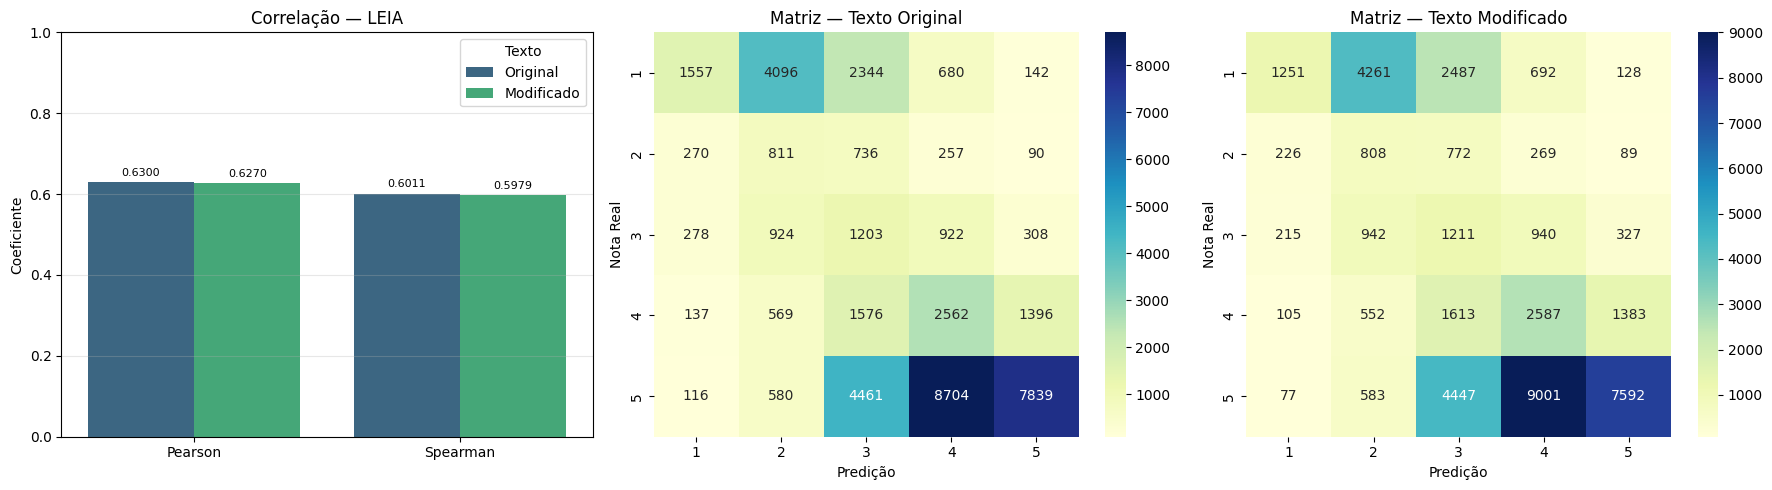

In [46]:
# CORRELAÇÕES
corr = pd.DataFrame({
    'Métrica': ['Pearson', 'Pearson', 'Spearman', 'Spearman'],
    'Texto': ['Original', 'Modificado', 'Original', 'Modificado'],
    'Correlação': [
        pearsonr(leia['nota_real'],leia['leia_estrelas_original'])[0],
        pearsonr(leia['nota_real'],leia['leia_estrelas_modificado'])[0],
        spearmanr(leia['nota_real'],leia['leia_estrelas_original'])[0],
        spearmanr(leia['nota_real'],leia['leia_estrelas_modificado'])[0]
    ]
})

# MATRIZ DE CONFUSÃO
cm_original = confusion_matrix(
    leia['nota_real'],
    leia['leia_estrelas_original'],
    labels=[1,2,3,4,5]
)

cm_modificado = confusion_matrix(
    leia['nota_real'],
    leia['leia_estrelas_modificado'],
    labels=[1,2,3,4,5]
)

# GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ax = sns.barplot(
    data=corr,
    x='Métrica',
    y='Correlação',
    hue='Texto',
    palette='viridis',
    ax=axes[0]
)

for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )

axes[0].set_title('Correlação — LEIA')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xlabel('')
axes[0].set_ylim(0,1)

axes[0].grid(axis='y', alpha=0.3)

# MATRIZES
sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[1]
)

axes[1].set_title('Matriz — Texto Original')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Nota Real')

sns.heatmap(
    cm_modificado,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[2]
)

axes[2].set_title('Matriz — Texto Modificado')
axes[2].set_xlabel('Predição')
axes[2].set_ylabel('Nota Real')

plt.tight_layout()
plt.show()

### 3.3 Transforms
Os modelos **Transformer** representam o estado da arte em tarefas modernas de Processamento de Linguagem Natural.

Diferentemente dos modelos baseados apenas em palavras isoladas, Transformers conseguem compreender:

- contexto
- relações semânticas
- negação
- intensidade emocional
- dependências entre palavras

Por possuírem maior complexidade computacional, os testes serão realizados inicialmente em uma amostra da base de dados.

**3.3.1 TRANSFORMER 1 — XLM-RoBERTa**

O **XLM-RoBERTa (Robustly Optimized BERT Approach)** é um modelo Transformer multilíngue treinado em diversos idiomas, incluindo português.

O modelo é capaz de compreender contexto textual de forma muito mais profunda que modelos baseados apenas em léxico, permitindo melhor interpretação de:

- frases negativas
- sarcasmo leve
- negações
- contexto semântico

In [ ]:
# !pip install sentencepiece tiktoken protobuf

In [8]:
# GPU / CPU
device = 0 if torch.cuda.is_available() else -1

print(f'\nUsando device: {device}')

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


# PIPELINE
classifier_xlmr = pipeline(
    task='sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    tokenizer='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    device=device
)


# CONVERSÃO SCORE -> ESTRELAS
def converter_para_estrelas(label, score):

    label = label.lower()

    if label == 'negative':

        if score >= 0.75:
            return 1
        else:
            return 2

    elif label == 'positive':

        if score >= 0.75:
            return 5
        else:
            return 4

    else:
        return 3

# EXECUTANDO INFERÊNCIA
print('\nExecutando inferência - texto original...')
textos_original = df_avaliacao['review_text'].tolist()

resultado_original = classifier_xlmr(
    textos_original,
    truncation=True,
    max_length=512,
    batch_size=32
)

print('\nExecutando inferência - texto modificado...')
textos_modificados = df_avaliacao['review_text_modificado'].tolist()
resultado_modificado = classifier_xlmr(
    textos_modificados,
    truncation=True,
    max_length=512,
    batch_size=32
)


# PROCESSAMENTO DOS RESULTADOS
def processar_resultados(resultados):

    linhas = []

    for r in resultados:

        try:

            label = r['label'].lower()
            score = round(r['score'], 4)

            estrelas = converter_para_estrelas(
                label,
                score
            )

            linhas.append({
                'label': label,
                'score': score,
                'estrelas': estrelas
            })

        except Exception as e:

            print(f'Erro ao processar resultado: {e}')

            linhas.append({
                'label': 'erro',
                'score': np.nan,
                'estrelas': np.nan
            })

    return pd.DataFrame(linhas)


# DATAFRAMES AUXILIARES
df_original = processar_resultados(resultado_original)
df_modificado = processar_resultados(resultado_modificado)


# COMPARAÇÃO FINAL
comparacao_roberta = pd.DataFrame({

    'comentario': df_avaliacao['review_text'],
    'nota_real': df_avaliacao['review_score'],

    # ORIGINAL
    'label_original': df_original['label'],
    'score_original': df_original['score'],
    'estrelas_original': df_original['estrelas'],

    # MODIFICADO
    'label_modificado': df_modificado['label'],
    'score_modificado': df_modificado['score'],
    'estrelas_modificado': df_modificado['estrelas']

})

comparacao_roberta.sample(10, random_state=32)


Usando device: 0
Tesla T4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Executando inferência - texto original...

Executando inferência - texto modificado...


,comentario,nota_real,label_original,score_original,estrelas_original,label_modificado,score_modificado,estrelas_modificado
25605,Esperava um produto original e veio uma réplic...,1,neutral,0.5466,3,neutral,0.7272,3
1434,"Muito bonito A Luminária é muito bonita, atend...",5,positive,0.9344,5,positive,0.7716,5
14610,"Eu achei a entrega um pouco demorada,e as espe...",2,negative,0.7162,2,negative,0.6813,2
26086,Bom produto,5,positive,0.7723,5,positive,0.6649,4
20456,O jogo de bolas de bilhar que comprei é totalm...,1,neutral,0.5823,3,neutral,0.8445,3
12203,Perfeito tudo de bom Chegou bem antes da data...,4,positive,0.9153,5,positive,0.8789,5
28058,Chegou antes do prazo. Tudo OK.,5,neutral,0.4844,3,neutral,0.6053,3
34030,"Produto entregue antes do prazo, muito bem emb...",5,positive,0.9335,5,positive,0.7814,5
22372,O material parece de camelo pelo preço não vale,3,neutral,0.5650,3,negative,0.7843,1
32089,Bom. Faltou a nota fiscal que não chegou com o...,4,negative,0.5109,2,negative,0.5613,2


In [10]:
comparacao_roberta.to_parquet("df_roberta.parquet")

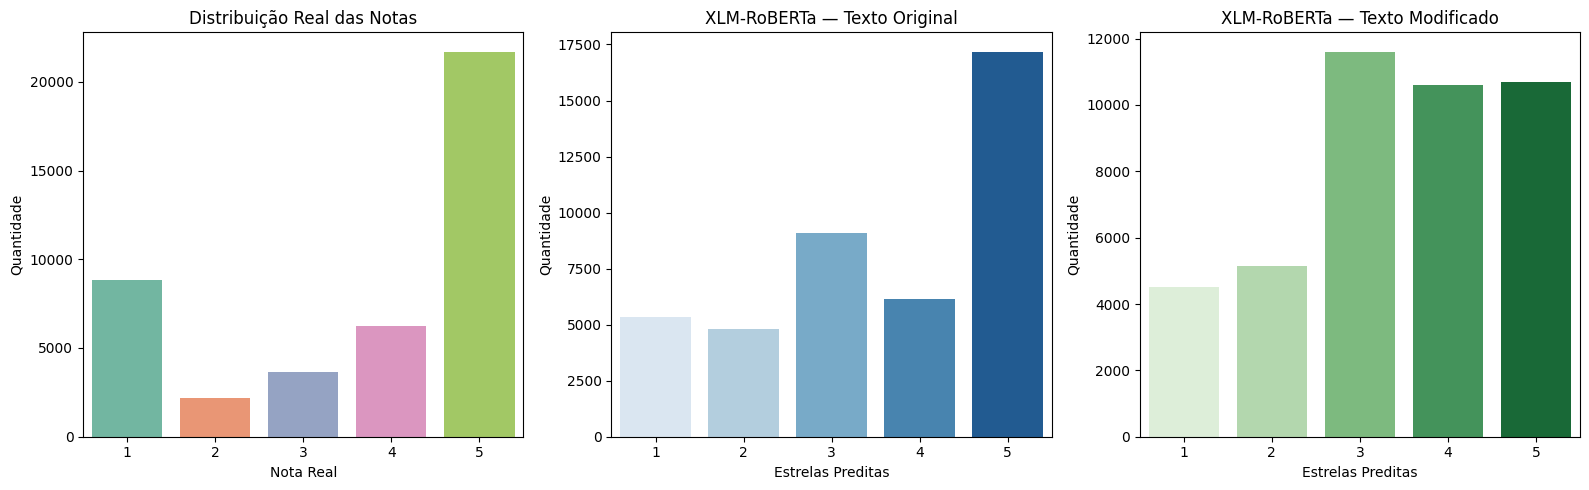

In [48]:
PATH = "./silver/df_roberta.parquet"
roberta = pd.read_parquet(PATH)


fig, axes = plt.subplots(1, 3, figsize=(16,5))

# GRÁFICO 1 - DISTRIBUIÇÃO REAL DAS NOTAS
sns.countplot(
    data=roberta,
    x='nota_real',
    order=[1,2,3,4,5],
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Distribuição Real das Notas')
axes[0].set_xlabel('Nota Real')
axes[0].set_ylabel('Quantidade')

# GRÁFICO 2 - XLM-RoBERTa TEXTO ORIGINAL
sns.countplot(
    data=roberta,
    x='estrelas_original',
    order=[1,2,3,4,5],
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('XLM-RoBERTa — Texto Original')
axes[1].set_xlabel('Estrelas Preditas')
axes[1].set_ylabel('Quantidade')

# GRÁFICO 3 - XLM-RoBERTa TEXTO MODIFICADO
sns.countplot(
    data=roberta,
    x='estrelas_modificado',
    order=[1,2,3,4,5],
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title('XLM-RoBERTa — Texto Modificado')
axes[2].set_xlabel('Estrelas Preditas')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

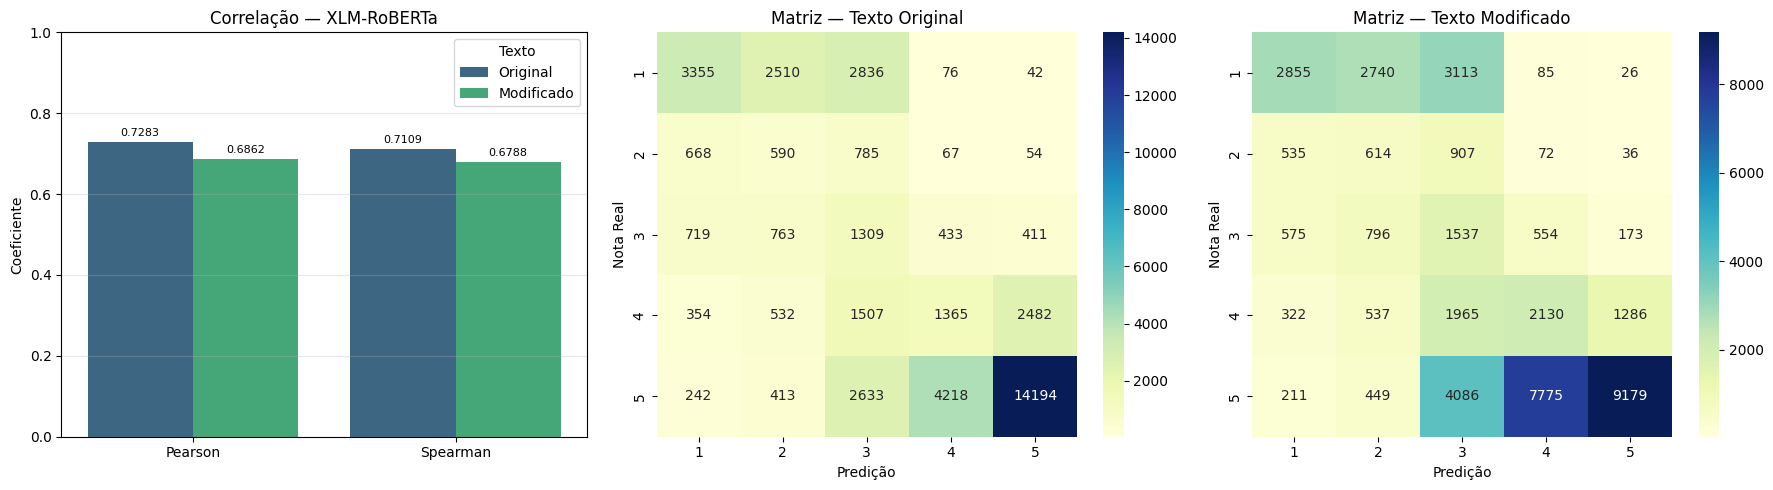

In [49]:
# CORRELAÇÕES
corr = pd.DataFrame({
    'Métrica': ['Pearson', 'Pearson', 'Spearman', 'Spearman'],
    'Texto': ['Original', 'Modificado', 'Original', 'Modificado'],
    'Correlação': [
        pearsonr(roberta['nota_real'],roberta['estrelas_original'])[0],
        pearsonr(roberta['nota_real'],roberta['estrelas_modificado'])[0],
        spearmanr(roberta['nota_real'],roberta['estrelas_original'])[0],
        spearmanr(roberta['nota_real'],roberta['estrelas_modificado'])[0]
    ]
})

# MATRIZ DE CONFUSÃO
cm_original = confusion_matrix(
    roberta['nota_real'],
    roberta['estrelas_original'],
    labels=[1,2,3,4,5]
)

cm_modificado = confusion_matrix(
    roberta['nota_real'],
    roberta['estrelas_modificado'],
    labels=[1,2,3,4,5]
)

# GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ax = sns.barplot(
    data=corr,
    x='Métrica',
    y='Correlação',
    hue='Texto',
    palette='viridis',
    ax=axes[0]
)

for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )

axes[0].set_title('Correlação — XLM-RoBERTa')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xlabel('')
axes[0].set_ylim(0,1)

axes[0].grid(axis='y', alpha=0.3)

# MATRIZES
sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[1]
)

axes[1].set_title('Matriz — Texto Original')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Nota Real')

sns.heatmap(
    cm_modificado,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[2]
)

axes[2].set_title('Matriz — Texto Modificado')
axes[2].set_xlabel('Predição')
axes[2].set_ylabel('Nota Real')

plt.tight_layout()
plt.show()

**3.3.2 TRANSFORMER 1 — BERT Multilingual Sentiment**

Este modelo **BERT** foi treinado especificamente para prever avaliações em formato de estrelas (1 a 5), tornando sua aplicação especialmente interessante para problemas relacionados à previsão de notas de avaliações.

O modelo transforma o texto em representações vetoriais contextualizadas e estima o nível de satisfação do consumidor com base no conteúdo do comentário.

Por já possuir treinamento voltado para avaliações, espera-se uma forte relação entre seus resultados e as notas reais atribuídas pelos usuários.

In [7]:
# GPU / CPU
device = 0 if torch.cuda.is_available() else -1
print(f'Usando device: {device}')

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


# PIPELINE
classifier_bert = pipeline(
    task='sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    tokenizer='nlptown/bert-base-multilingual-uncased-sentiment',
    device=device
)

# EXECUTANDO INFERÊNCIA
print('\nExecutando inferência - texto original...')
textos_original = df_avaliacao['review_text'].tolist()

resultado_original = classifier_bert(
    textos_original,
    truncation=True,
    max_length=512,
    batch_size=32
)

print('\nExecutando inferência - texto modificado...')
textos_modificados = df_avaliacao['review_text_modificado'].tolist()

resultado_modificado = classifier_bert(
    textos_modificados,
    truncation=True,
    max_length=512,
    batch_size=64
)

# FUNÇÃO SCORE
def processar_resultados(resultados):

    linhas = []

    for r in resultados:

        label = r['label']
        score = round(r['score'], 4)

        estrelas = int(label[0])

        linhas.append({
            'label': label,
            'score': score,
            'estrelas': estrelas
        })

    return pd.DataFrame(linhas)


# DATAFRAMES AUXILIARES
df_original = processar_resultados(resultado_original)
df_modificado = processar_resultados(resultado_modificado)


# COMPARAÇÃO FINAL
comparacao_bert = pd.DataFrame({

    'comentario': df_avaliacao['review_text'].values,
    'nota_real': df_avaliacao['review_score'].values,

    # ORIGINAL
    'score_original': df_original['score'].values,
    'estrelas_original': df_original['estrelas'].values,

    # MODIFICADO
    'score_modificado': df_modificado['score'].values,
    'estrelas_modificado': df_modificado['estrelas'].values
})

comparacao_bert.sample(10, random_state=32)

Usando device: 0
Tesla T4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Executando inferência - texto original...

Executando inferência - texto modificado...


,comentario,nota_real,score_original,estrelas_original,score_modificado,estrelas_modificado
25605,Esperava um produto original e veio uma réplic...,1,0.2984,2,0.3017,3
1434,"Muito bonito A Luminária é muito bonita, atend...",5,0.6347,5,0.4964,4
14610,"Eu achei a entrega um pouco demorada,e as espe...",2,0.5089,3,0.3234,2
26086,Bom produto,5,0.4671,4,0.4671,4
20456,O jogo de bolas de bilhar que comprei é totalm...,1,0.5558,1,0.5183,1
12203,Perfeito tudo de bom Chegou bem antes da data...,4,0.7229,5,0.5957,5
28058,Chegou antes do prazo. Tudo OK.,5,0.4622,5,0.4902,5
34030,"Produto entregue antes do prazo, muito bem emb...",5,0.6601,5,0.2820,3
22372,O material parece de camelo pelo preço não vale,3,0.4774,1,0.5643,1
32089,Bom. Faltou a nota fiscal que não chegou com o...,4,0.3771,3,0.6011,1


In [8]:
comparacao_bert.to_parquet("df_bert.parquet")

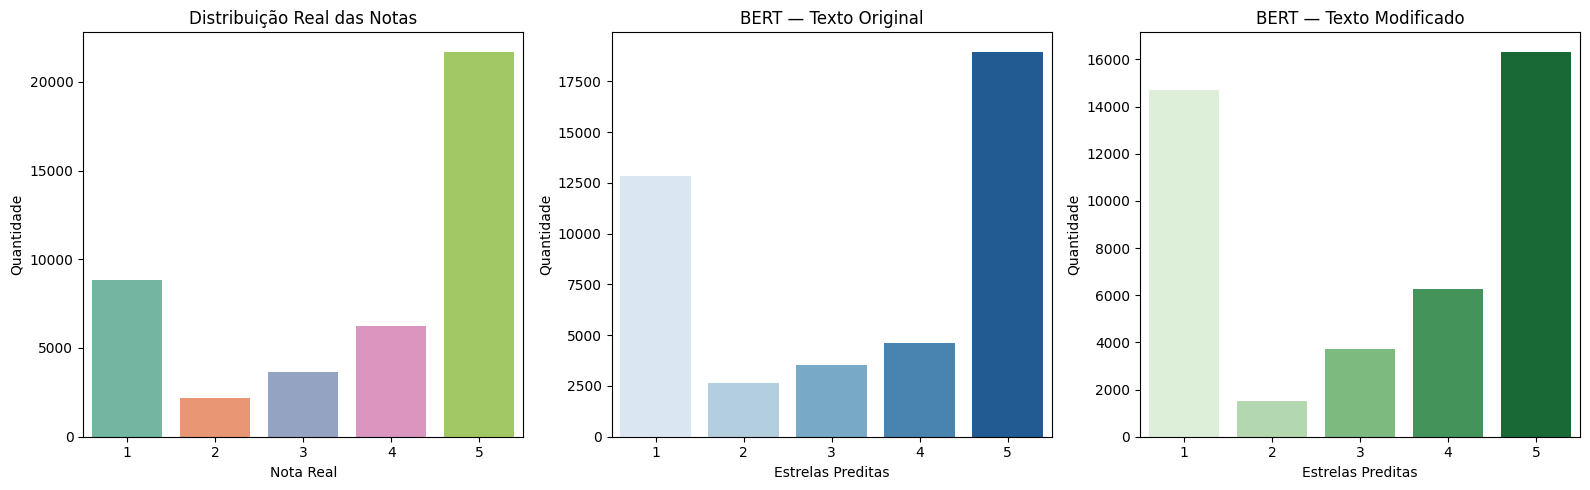

In [9]:
PATH = "./silver/df_bert.parquet"
bert = pd.read_parquet(PATH)


fig, axes = plt.subplots(1, 3, figsize=(16,5))

# GRÁFICO 1 - DISTRIBUIÇÃO REAL DAS NOTAS
sns.countplot(
    data=bert,
    x='nota_real',
    order=[1,2,3,4,5],
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Distribuição Real das Notas')
axes[0].set_xlabel('Nota Real')
axes[0].set_ylabel('Quantidade')

# GRÁFICO 2 - BERT TEXTO ORIGINAL
sns.countplot(
    data=bert,
    x='estrelas_original',
    order=[1,2,3,4,5],
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('BERT — Texto Original')
axes[1].set_xlabel('Estrelas Preditas')
axes[1].set_ylabel('Quantidade')

# GRÁFICO 3 - BERT TEXTO MODIFICADO
sns.countplot(
    data=bert,
    x='estrelas_modificado',
    order=[1,2,3,4,5],
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title('BERT — Texto Modificado')
axes[2].set_xlabel('Estrelas Preditas')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

array([[ 7931,   203,   302,   142,   241],
       [ 1649,   162,   181,    79,    93],
       [ 1843,   265,   640,   400,   487],
       [ 1230,   247,   892,  1538,  2333],
       [ 2029,   659,  1720,  4114, 13178]], dtype=int64)

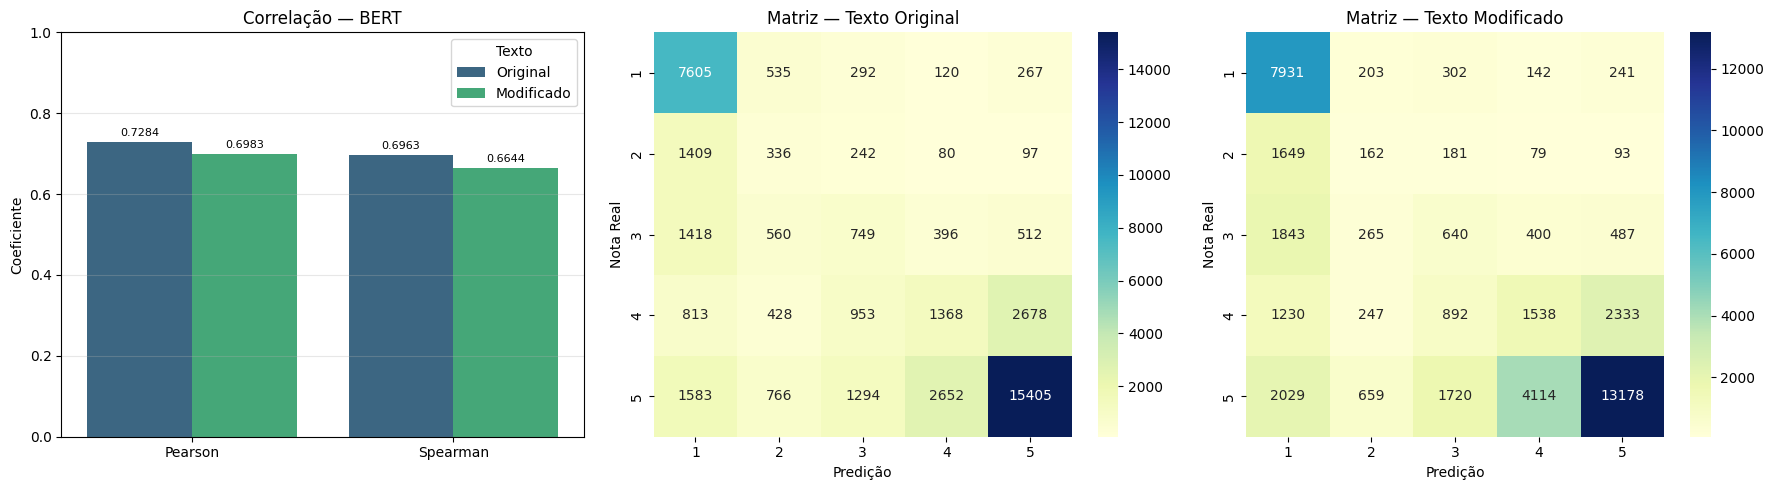

In [55]:
# CORRELAÇÕES
corr = pd.DataFrame({
    'Métrica': ['Pearson', 'Pearson', 'Spearman', 'Spearman'],
    'Texto': ['Original', 'Modificado', 'Original', 'Modificado'],
    'Correlação': [
        pearsonr(bert['nota_real'],bert['estrelas_original'])[0],
        pearsonr(bert['nota_real'],bert['estrelas_modificado'])[0],
        spearmanr(bert['nota_real'],bert['estrelas_original'])[0],
        spearmanr(bert['nota_real'],bert['estrelas_modificado'])[0]
    ]
})

# MATRIZ DE CONFUSÃO
cm_original = confusion_matrix(
    bert['nota_real'],
    bert['estrelas_original'],
    labels=[1,2,3,4,5]
)

cm_modificado = confusion_matrix(
    bert['nota_real'],
    bert['estrelas_modificado'],
    labels=[1,2,3,4,5]
)

# GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ax = sns.barplot(
    data=corr,
    x='Métrica',
    y='Correlação',
    hue='Texto',
    palette='viridis',
    ax=axes[0]
)

for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )

axes[0].set_title('Correlação — BERT')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xlabel('')
axes[0].set_ylim(0,1)

axes[0].grid(axis='y', alpha=0.3)

# MATRIZES
sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[1]
)

axes[1].set_title('Matriz — Texto Original')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Nota Real')

sns.heatmap(
    cm_modificado,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[2]
)

axes[2].set_title('Matriz — Texto Modificado')
axes[2].set_xlabel('Predição')
axes[2].set_ylabel('Nota Real')

plt.tight_layout()
plt.show()

**3.3.3**

In [5]:
# ANALYZER
analyzer = create_analyzer(
    task='sentiment',
    lang='pt'
)

# CONVERSÃO SCORE -> ESTRELAS
def converter_para_estrelas(label, score):

    label = label.upper()

    if label == 'NEG':

        if score >= 0.75:
            return 1
        else:
            return 2

    elif label == 'POS':

        if score >= 0.75:
            return 5
        else:
            return 4

    else:
        return 3
    
# EXECUTANDO INFERÊNCIA

print('\nExecutando inferência - texto original...')
textos_original = df_avaliacao['review_text'].tolist()

resultado_original = [
    analyzer.predict(texto)
    for texto in tqdm(textos_original)
]

print('\nExecutando inferência - texto modificado...')
textos_modificados = df_avaliacao['review_text_modificado'].tolist()

resultado_modificado = [
    analyzer.predict(texto)
    for texto in tqdm(textos_modificados)
]

# PROCESSANDO OS RESULTADOS
def processar_resultados(resultados):

    linhas = []

    for r in resultados:

        try:

            label = r.output.upper()

            score = round(
                r.probas[label],
                4
            )

            estrelas = converter_para_estrelas(
                label,
                score
            )

            linhas.append({

                'label': label,
                'score': score,
                'estrelas': estrelas
            })

        except Exception as e:

            print(f'Erro: {e}')

            linhas.append({

                'label': 'erro',
                'score': np.nan,
                'estrelas': np.nan
            })

    return pd.DataFrame(linhas)


# DATAFRAMES AUXILIARES
df_original = processar_resultados(resultado_original)
df_modificado = processar_resultados(resultado_modificado)

# COMPARAÇÃO FINAL
comparacao_pysentimiento = pd.DataFrame({

    'comentario': df_avaliacao['review_text'],
    'nota_real': df_avaliacao['review_score'],

    # ORIGINAL
    'label_original': df_original['label'],
    'score_original': df_original['score'],
    'estrelas_original': df_original['estrelas'],

    # MODIFICADO
    'label_modificado': df_modificado['label'],
    'score_modificado': df_modificado['score'],
    'estrelas_modificado': df_modificado['estrelas']
})

comparacao_pysentimiento.sample(10, random_state=32)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4481.69it/s]



Executando inferência - texto original...


100%|██████████| 42558/42558 [1:48:35<00:00,  6.53it/s]     



Executando inferência - texto modificado...


100%|██████████| 42558/42558 [58:53<00:00, 12.05it/s]  


,comentario,nota_real,label_original,score_original,estrelas_original,label_modificado,score_modificado,estrelas_modificado
25605,Esperava um produto original e veio uma réplic...,1,NEG,0.6372,2,NEU,0.7807,3
1434,"Muito bonito A Luminária é muito bonita, atend...",5,POS,0.9903,5,POS,0.9915,5
14610,"Eu achei a entrega um pouco demorada,e as espe...",2,NEG,0.8438,1,NEG,0.8354,1
26086,Bom produto,5,POS,0.9758,5,POS,0.9626,5
20456,O jogo de bolas de bilhar que comprei é totalm...,1,NEU,0.9198,3,NEU,0.8899,3
12203,Perfeito tudo de bom Chegou bem antes da data...,4,POS,0.9923,5,POS,0.9924,5
28058,Chegou antes do prazo. Tudo OK.,5,NEU,0.8374,3,NEU,0.6507,3
34030,"Produto entregue antes do prazo, muito bem emb...",5,POS,0.9897,5,POS,0.9705,5
22372,O material parece de camelo pelo preço não vale,3,NEG,0.9878,1,NEG,0.9823,1
32089,Bom. Faltou a nota fiscal que não chegou com o...,4,NEG,0.7000,2,NEU,0.5287,3


In [6]:
comparacao_pysentimiento.to_parquet("df_pysentimiento.parquet")


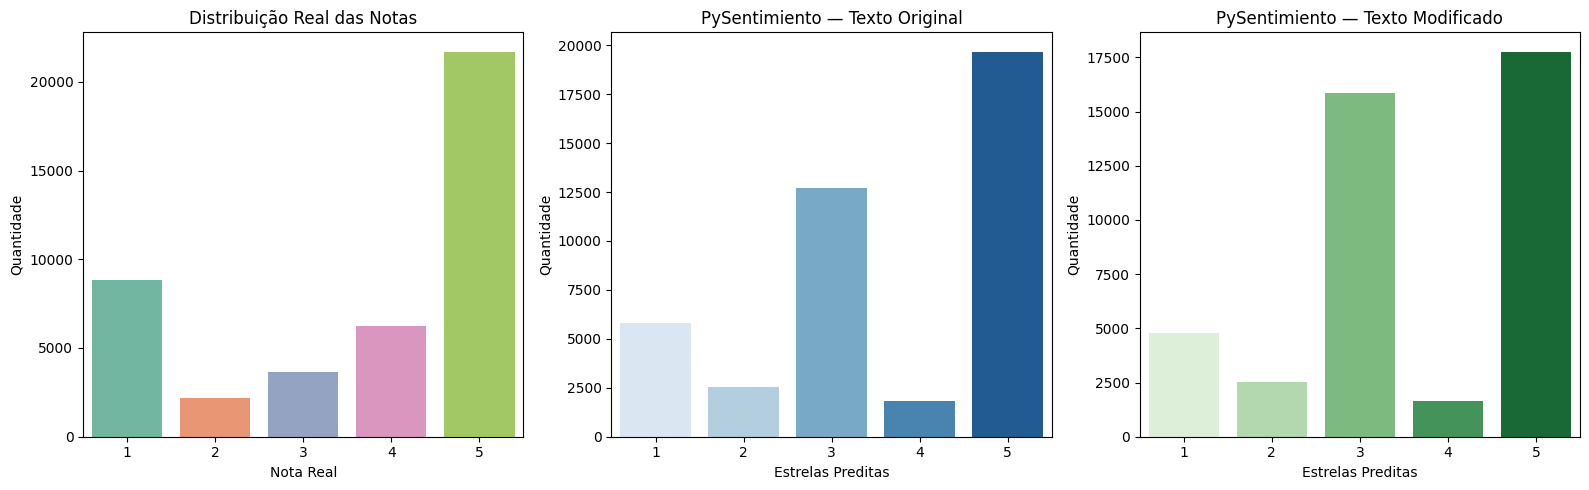

In [7]:
PATH = "./silver/df_pysentimiento.parquet"
pysenti = pd.read_parquet(PATH)


fig, axes = plt.subplots(1, 3, figsize=(16,5))

# GRÁFICO 1 - DISTRIBUIÇÃO REAL DAS NOTAS
sns.countplot(
    data=pysenti,
    x='nota_real',
    order=[1,2,3,4,5],
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Distribuição Real das Notas')
axes[0].set_xlabel('Nota Real')
axes[0].set_ylabel('Quantidade')

# GRÁFICO 2 - PYSENTIMIENTO TEXTO ORIGINAL
sns.countplot(
    data=pysenti,
    x='estrelas_original',
    order=[1,2,3,4,5],
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('PySentimiento — Texto Original')
axes[1].set_xlabel('Estrelas Preditas')
axes[1].set_ylabel('Quantidade')

# GRÁFICO 3 - PYSENTIMIENTO TEXTO MODIFICADO
sns.countplot(
    data=pysenti,
    x='estrelas_modificado',
    order=[1,2,3,4,5],
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title('PySentimiento — Texto Modificado')
axes[2].set_xlabel('Estrelas Preditas')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

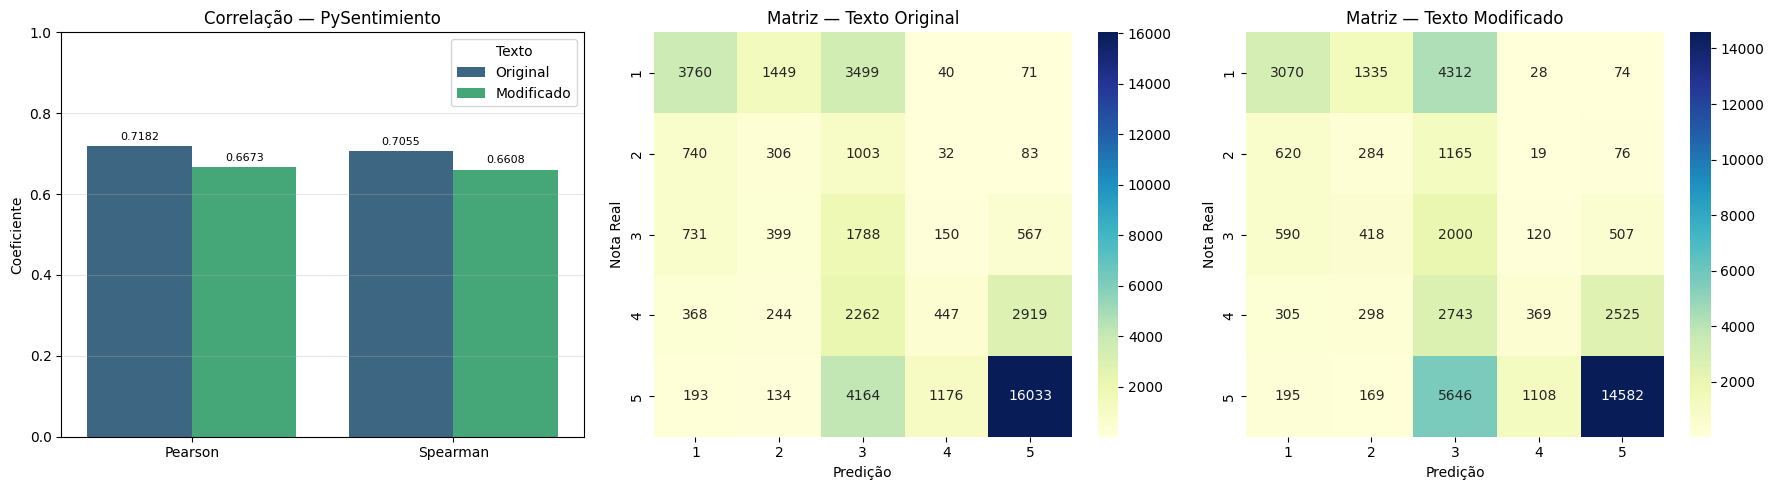

In [8]:
# CORRELAÇÕES
corr = pd.DataFrame({
    'Métrica': ['Pearson', 'Pearson', 'Spearman', 'Spearman'],
    'Texto': ['Original', 'Modificado', 'Original', 'Modificado'],
    'Correlação': [
        pearsonr(pysenti['nota_real'],pysenti['estrelas_original'])[0],
        pearsonr(pysenti['nota_real'],pysenti['estrelas_modificado'])[0],
        spearmanr(pysenti['nota_real'],pysenti['estrelas_original'])[0],
        spearmanr(pysenti['nota_real'],pysenti['estrelas_modificado'])[0]
    ]
})

# MATRIZ DE CONFUSÃO
cm_original = confusion_matrix(
    pysenti['nota_real'],
    pysenti['estrelas_original'],
    labels=[1,2,3,4,5]
)

cm_modificado = confusion_matrix(
    pysenti['nota_real'],
    pysenti['estrelas_modificado'],
    labels=[1,2,3,4,5]
)

# GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(18,5))

ax = sns.barplot(
    data=corr,
    x='Métrica',
    y='Correlação',
    hue='Texto',
    palette='viridis',
    ax=axes[0]
)

for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=8
    )

axes[0].set_title('Correlação — PySentimiento')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xlabel('')
axes[0].set_ylim(0,1)

axes[0].grid(axis='y', alpha=0.3)

# MATRIZES
sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[1]
)

axes[1].set_title('Matriz — Texto Original')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Nota Real')

sns.heatmap(
    cm_modificado,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5],
    ax=axes[2]
)

axes[2].set_title('Matriz — Texto Modificado')
axes[2].set_xlabel('Predição')
axes[2].set_ylabel('Nota Real')

plt.tight_layout()
plt.show()